In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']=(10,5)

from voxforge.data.load import load_all
from voxforge.data.config import INTERIM_DATA_DIR, REPORTS_DIR
from voxforge.data.merge import merge_datasets
from voxforge.data.profile import dataset_overview, text_statistics, vocabulary_size, data_quality_report,generate_profile

import json

In [3]:
# load all the 3 datasets
datasets = load_all()
df_merged = merge_datasets(datasets)

df_merged.shape

INFO - Loaded 34660 rows
INFO - Loaded 5000 rows
INFO - Loaded 28332 rows
INFO - Loaded 3 datasets.


(67992, 28)

In [4]:
df_merged.head(5)

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.userCity,reviews.userProvince,reviews.username,source_dataset,dateAdded,dateUpdated,primaryCategories,imageURLs,manufacturerNumber,sourceURLs
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,NaN,NaN,Adapter,1429_1,NaN,NaN,NaN,NaN,NaN,NaN
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,NaN,NaN,truman,1429_1,NaN,NaN,NaN,NaN,NaN,NaN
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,NaN,NaN,DaveZ,1429_1,NaN,NaN,NaN,NaN,NaN,NaN
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,NaN,NaN,Shacks,1429_1,NaN,NaN,NaN,NaN,NaN,NaN
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,NaN,NaN,explore42,1429_1,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# saved the merged the 3 raw dataset under /data/processed
INTERIM_DATA_DIR.mkdir(parents=True, exist_ok=True)

output_path = INTERIM_DATA_DIR / "merged_reviews.csv"

df_merged.to_csv(
    output_path,
    index=False,
)

print(f"Merged dataset saved to: {output_path}")

Merged dataset saved to: /Users/karima/Ironhack-challenges/voxforge-ai-review-analytics/data/interim/merged_reviews.csv


In [6]:
# datasset overview
dataset_overview(df_merged)

,Metric,Value
0,Rows,67992.00
1,Columns,28.00
2,Duplicate Rows,95.00
3,Memory Usage (MB),464.05
4,Total Missing Values,555201.00


In [7]:
# Column information
df_merged.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 67992 entries, 0 to 67991
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    67992 non-null  str    
 1   name                  61232 non-null  str    
 2   asins                 67990 non-null  str    
 3   brand                 67992 non-null  str    
 4   categories            67992 non-null  str    
 5   keys                  67992 non-null  str    
 6   manufacturer          67992 non-null  str    
 7   reviews.date          67953 non-null  str    
 8   reviews.dateAdded     25091 non-null  str    
 9   reviews.dateSeen      67992 non-null  str    
 10  reviews.didPurchase   10 non-null     object 
 11  reviews.doRecommend   55152 non-null  object 
 12  reviews.id            71 non-null     float64
 13  reviews.numHelpful    55246 non-null  float64
 14  reviews.rating        67959 non-null  float64
 15  reviews.sourceURLs    67992 no

In [8]:
# Check missing values
df_merged.isna().sum()

id                          0
name                     6760
asins                       2
brand                       0
categories                  0
keys                        0
manufacturer                0
reviews.date               39
reviews.dateAdded       42901
reviews.dateSeen            0
reviews.didPurchase     67982
reviews.doRecommend     12840
reviews.id              67921
reviews.numHelpful      12746
reviews.rating             33
reviews.sourceURLs          0
reviews.text                1
reviews.title              19
reviews.userCity        67992
reviews.userProvince    67992
reviews.username           13
source_dataset              0
dateAdded               34660
dateUpdated             34660
primaryCategories       34660
imageURLs               34660
manufacturerNumber      34660
sourceURLs              34660
dtype: int64

Ivestigate why do we have reviews.doRecommend about 12746 missing

In [9]:
missing_recommend = df_merged["reviews.doRecommend"].isna().sum()

print(f"Missing values: {missing_recommend}")
print(f"Percentage: {missing_recommend / len(df_merged):.2%}")

Missing values: 12840
Percentage: 18.88%


Investigate what values exist for recommend

In [10]:
df_merged["reviews.doRecommend"].value_counts(dropna=False)

reviews.doRecommend
True     52800
NaN      12840
False     2352
Name: count, dtype: int64

In [11]:
import pandas as pd

pd.crosstab(
    df_merged["reviews.rating"],
    df_merged["reviews.doRecommend"],
    dropna=False,
)

reviews.doRecommend,False,True,NaN
reviews.rating,,,
1.0,592,33,813
2.0,563,85,424
3.0,876,1450,576
4.0,222,13685,1490
5.0,99,37547,9504
NaN,0,0,33


Key learnings:
for 5 reviews
True      37,547
Missing    9,504
False         99
- The missing values are concentrated among positive reviews.
- Interestengly many missing values also occur among negative reviews.

***key decision***  Missing recommendations are structural so we will keep them.

In [12]:
# which dataset contains missing values
pd.crosstab(
    df_merged["source_dataset"],
    df_merged["reviews.doRecommend"].isna()
)

reviews.doRecommend,False,True
source_dataset,,
1429_1,34066,594
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products,5000,0
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19,16086,12246


Key learnings:
The May19 dataset contains 28,332 rows which i almost half of that dataset has no recommendation value.
Meanwhile the other two datasets have zero missing values. Which means the missing values are dataset-specific.
We have structural missingness.

Conclusion:
The reviews.doRecommend column contains 12,840 missing values (18.9%). Investigation showed that all missing values originate almost exclusively from the Datafiniti Amazon Consumer Reviews May19 dataset. This indicates structural missingness caused by differences in the source datasets rather than random data corruption. Since recommendation cannot be reliably inferred from the review rating or text, the missing values will be preserved rather than dropped.

INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


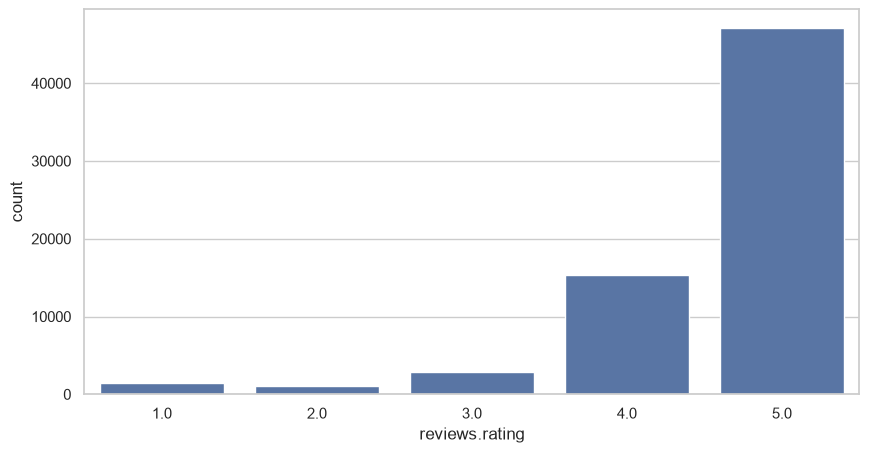

reviews.rating
1.0     1438
2.0     1072
3.0     2902
4.0    15397
5.0    47150
NaN       33
Name: count, dtype: int64

In [ ]:
# Rating (label) Distribution
sns.countplot(data=df_merged,x='reviews.rating');plt.show()
display(df_merged['reviews.rating'].value_counts(dropna=False).sort_index())

**Key learning:** • The dataset is highly imbalanced toward positive ratings. Therefore precision score will be high and we will need to rely on other metrics like Precision, Recall, F1-score, Macro F1 and Confusion Matrixas metrics to evaluate different models.

In [14]:
# Analyze duplicates
df_merged.duplicated().sum()

np.int64(95)

***Key Decisions***: Remove the 95 rows of duplicats

In [15]:
# check unique values
display(
    df_merged["reviews.rating"]
    .value_counts(dropna=False)
    .sort_index()
)

print("Unique category strings:", df_merged["categories"].nunique())

reviews.rating
1.0     1438
2.0     1072
3.0     2902
4.0    15397
5.0    47150
NaN       33
Name: count, dtype: int64

Unique category strings: 111


In [16]:
# create numerical summary 
df_merged.describe()

,reviews.id,reviews.numHelpful,reviews.rating,reviews.userCity,reviews.userProvince
count,7.100000e+01,55246.000000,67959.000000,0.0,0.0
mean,1.837463e+08,0.572041,4.556071,NaN,NaN
std,2.371858e+07,11.587020,0.825126,NaN,NaN
min,1.082112e+08,0.000000,1.000000,NaN,NaN
25%,1.843760e+08,0.000000,4.000000,NaN,NaN
50%,1.880757e+08,0.000000,5.000000,NaN,NaN
75%,1.987126e+08,0.000000,5.000000,NaN,NaN
max,2.085304e+08,814.000000,5.000000,NaN,NaN


In [17]:
# text profiling
text_statistics(df_merged)

,Metric,Value
0,Average Characters,150.24
1,Median Characters,99.00
2,Minimum Characters,0.00
3,Maximum Characters,10670.00
4,Average Words,28.59
5,Median Words,19.00
6,Minimum Words,0.00
7,Maximum Words,1858.00


In [18]:
# calculate vocabulary size
vocabulary_size(df_merged)

39937

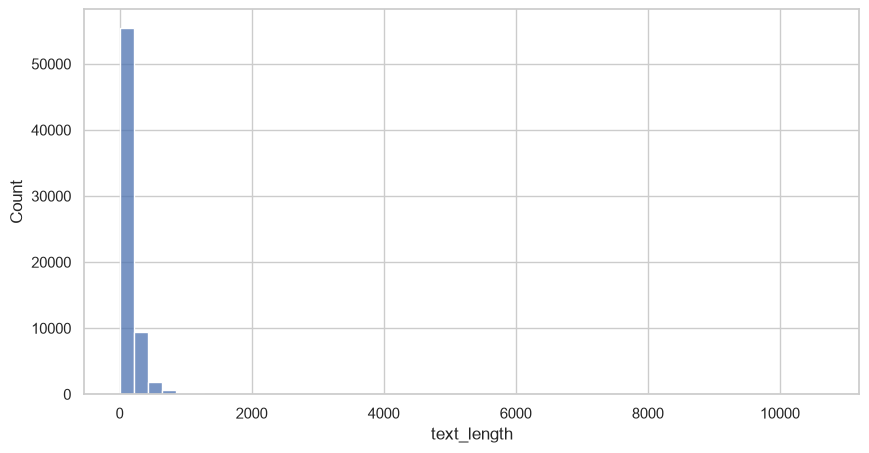

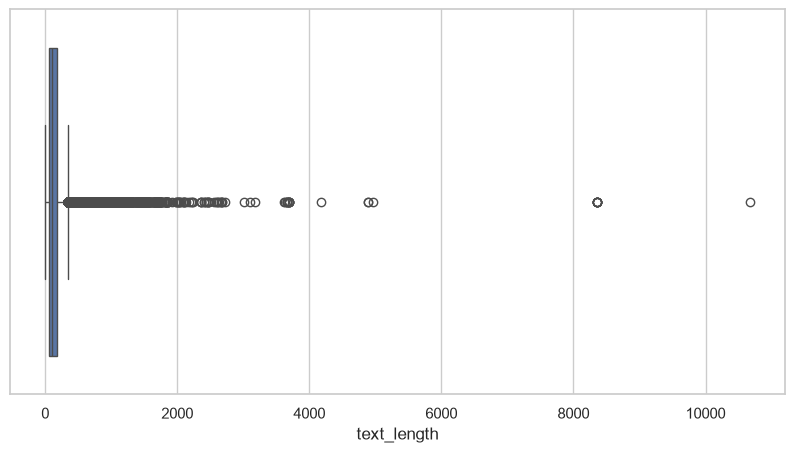

,reviews.title,reviews.rating,text_length,source_dataset
21231,Superb reading device - but which one's best f...,5.0,10670,1429_1
2932,Great price on an awesome little tablet,4.0,8351,1429_1
37024,Great price on an awesome little tablet,4.0,8351,Datafiniti_Amazon_Consumer_Reviews_of_Amazon_P...
39531,Great price on an awesome little tablet,4.0,8351,Datafiniti_Amazon_Consumer_Reviews_of_Amazon_P...
55094,Great price on an awesome little tablet,4.0,8351,Datafiniti_Amazon_Consumer_Reviews_of_Amazon_P...


In [19]:
# Review text length
df_merged['text_length']=df_merged['reviews.text'].fillna('').str.len()
sns.histplot(df_merged['text_length'],bins=50);plt.show()
sns.boxplot(x=df_merged['text_length']);plt.show()
display(df_merged.nlargest(5,'text_length')[['reviews.title','reviews.rating','text_length','source_dataset']])

***Decision:** Inspect outliers before removal.

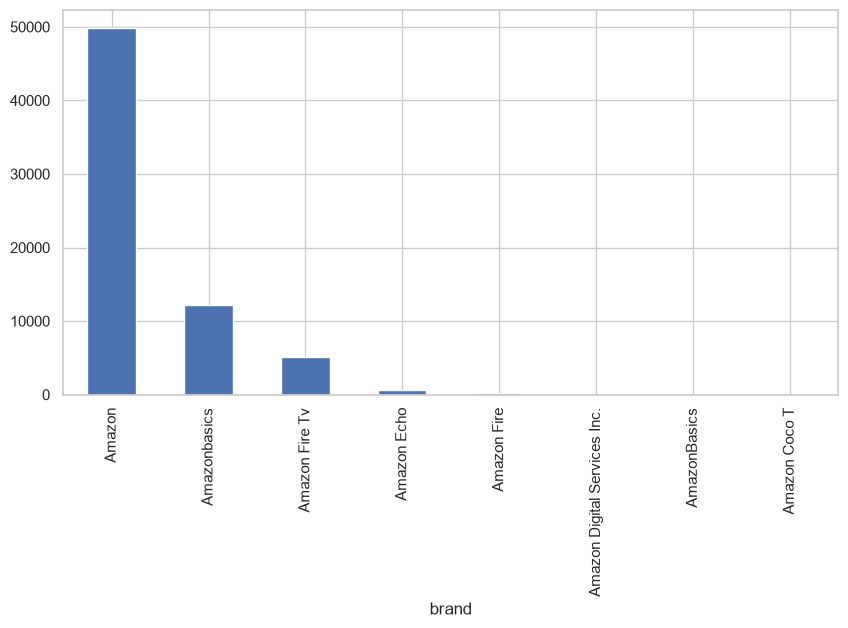

brand
Amazon Fire Tv                  4.707278
Amazon                          4.567259
Amazon Fire                     4.558594
Amazon Echo                     4.531447
Amazonbasics                    4.449749
AmazonBasics                    4.300000
Amazon Digital Services Inc.    3.500000
Amazon Coco T                        NaN
Name: reviews.rating, dtype: float64

In [20]:
# plot brands
df_merged['brand'].value_counts().head(10).plot(kind='bar');plt.show()
display(df_merged.groupby('brand')['reviews.rating'].mean().sort_values(ascending=False).head(10))

**Key Decision:** Keep brand as a feature.

categories
Fire Tablets,Tablets,Computers & Tablets,All Tablets,Electronics, Tech Toys, Movies, Music,Electronics,iPad & Tablets,Android Tablets,Frys                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               10966
AA,AAA,Health,Electronics,Health & Household,Camcorder Batteries,Camera & Photo,Batteries,Household Batteries,Robot Check,Accessories,Camera Batteries,Health and Beauty,Household Supplies,Batteries & Chargers,Health, Household & Baby Care,Health Personal

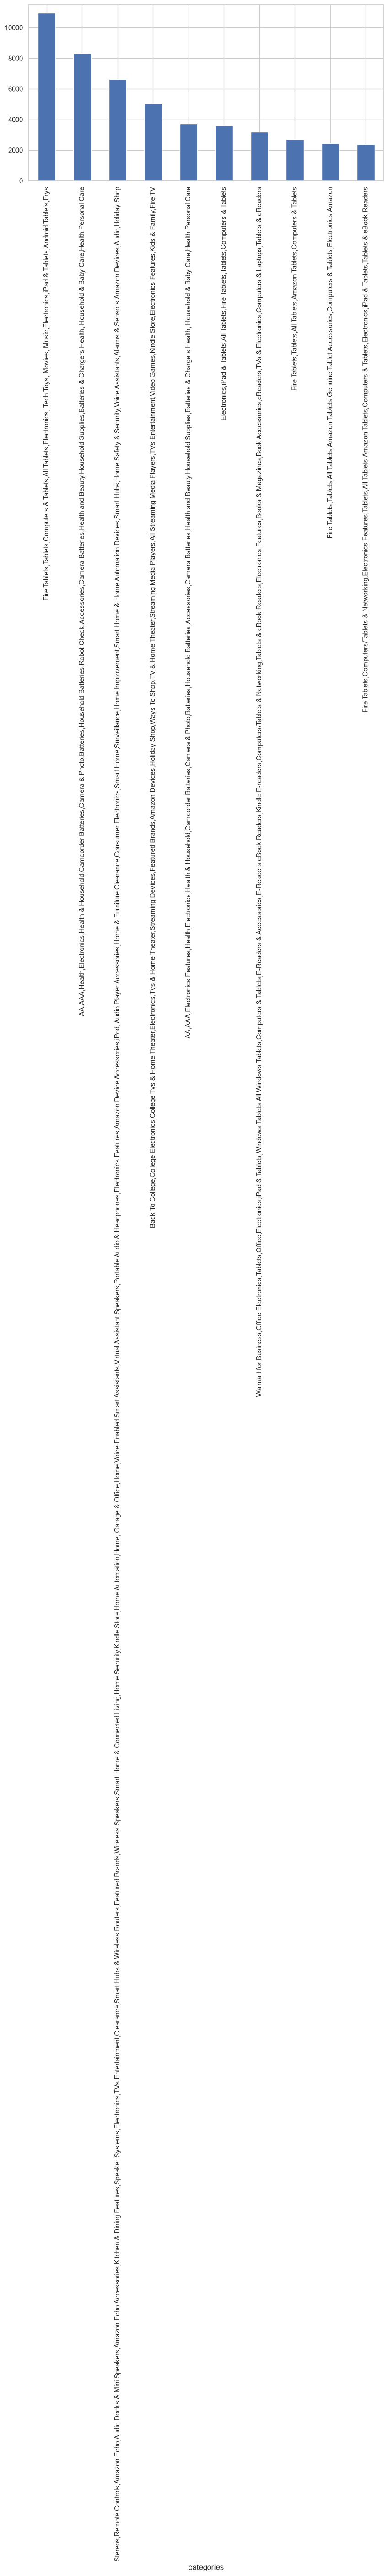

In [21]:
# plot categories
display(df_merged['categories'].value_counts().head(10))
df_merged['categories'].value_counts().head(10).plot(kind='bar');plt.show()

In [22]:
# sourced dataset

,reviews,avg_rating,avg_length,missing_recommend
source_dataset,,,,
1429_1,34660,4.584573,159.042845,594
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products,5000,4.596800,161.348400,0
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19,28332,4.514048,137.517118,12246


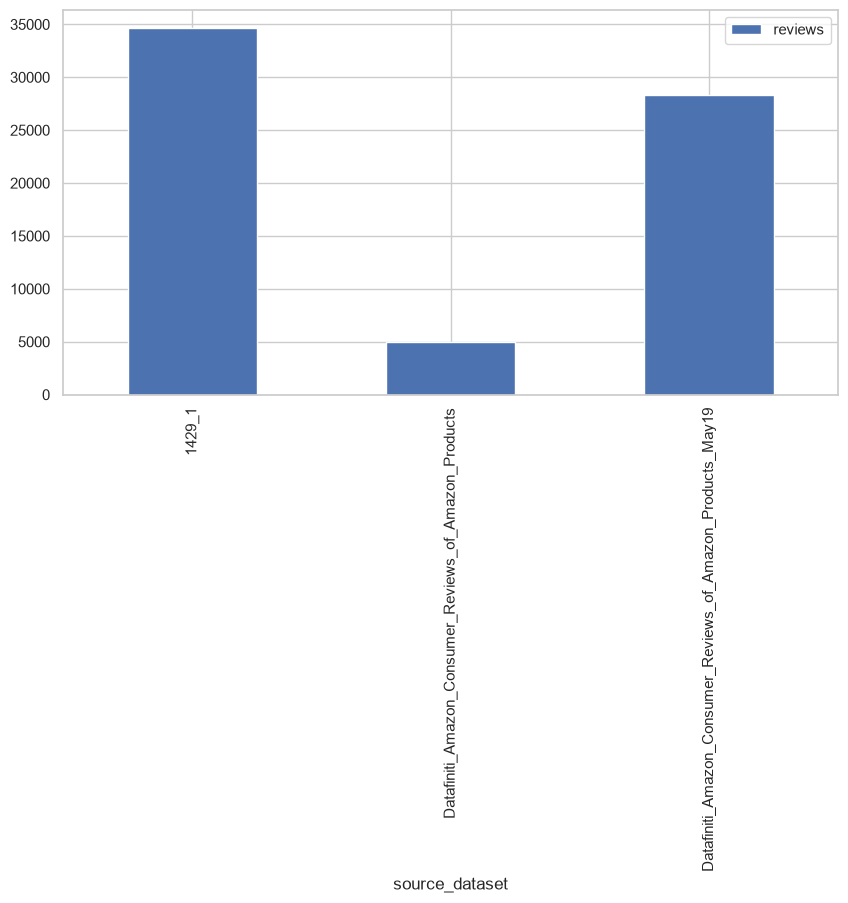

In [23]:
## Source Dataset
summary=df_merged.groupby('source_dataset').agg(reviews=('source_dataset','size'),avg_rating=('reviews.rating','mean'),avg_length=('text_length','mean'),missing_recommend=('reviews.doRecommend',lambda x:x.isna().sum()))
display(summary)
summary[['reviews']].plot(kind='bar');plt.show()

**Key Decision:** Preserve source_dataset for traceability

In [24]:
# generate data quality overview
report = data_quality_report(df_merged)

report

{'rows': 67992,
 'columns': 29,
 'duplicates': 95,
 'missing_values': {'id': 0,
  'name': 6760,
  'asins': 2,
  'brand': 0,
  'categories': 0,
  'keys': 0,
  'manufacturer': 0,
  'reviews.date': 39,
  'reviews.dateAdded': 42901,
  'reviews.dateSeen': 0,
  'reviews.didPurchase': 67982,
  'reviews.doRecommend': 12840,
  'reviews.id': 67921,
  'reviews.numHelpful': 12746,
  'reviews.rating': 33,
  'reviews.sourceURLs': 0,
  'reviews.text': 1,
  'reviews.title': 19,
  'reviews.userCity': 67992,
  'reviews.userProvince': 67992,
  'reviews.username': 13,
  'source_dataset': 0,
  'dateAdded': 34660,
  'dateUpdated': 34660,
  'primaryCategories': 34660,
  'imageURLs': 34660,
  'manufacturerNumber': 34660,
  'sourceURLs': 34660,
  'text_length': 0},
 'data_types': {'id': 'str',
  'name': 'str',
  'asins': 'str',
  'brand': 'str',
  'categories': 'str',
  'keys': 'str',
  'manufacturer': 'str',
  'reviews.date': 'str',
  'reviews.dateAdded': 'str',
  'reviews.dateSeen': 'str',
  'reviews.didPurc

## Summary
- The merged dataset successfully combines three Amazon review datasets into a single analysis-ready dataset.
- Most data quality issues are explainable rather than random, particularly the structurally missing recommendation values.
- The target variable (reviews.rating) is highly imbalanced, requiring appropriate evaluation metrics during model training.
- Duplicate records and duplicated review texts should be removed to prevent bias.
- Text preprocessing will be required to normalize review content before feature extraction.
- Product brand, category, and source dataset contain valuable contextual information and should be preserved.
- Review length and recommendation provide useful analytical insights, even if they are not directly used as prediction targets.

In [25]:
# Export data quality report
profile = generate_profile(df_merged)

with open(
    REPORTS_DIR / "data_profile.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        profile["quality_report"],
        f,
        indent=4,
        ensure_ascii=False,
    )

In [26]:
# geneate the 3 data profiles
profile = generate_profile(df_merged)

display(profile["overview"])
display(profile["text_statistics"])
profile["quality_report"]

,Metric,Value
0,Rows,67992.00
1,Columns,29.00
2,Duplicate Rows,95.00
3,Memory Usage (MB),464.57
4,Total Missing Values,555201.00


,Metric,Value
0,Average Characters,150.24
1,Median Characters,99.00
2,Minimum Characters,0.00
3,Maximum Characters,10670.00
4,Average Words,28.59
5,Median Words,19.00
6,Minimum Words,0.00
7,Maximum Words,1858.00


{'rows': 67992,
 'columns': 29,
 'duplicates': 95,
 'missing_values': {'id': 0,
  'name': 6760,
  'asins': 2,
  'brand': 0,
  'categories': 0,
  'keys': 0,
  'manufacturer': 0,
  'reviews.date': 39,
  'reviews.dateAdded': 42901,
  'reviews.dateSeen': 0,
  'reviews.didPurchase': 67982,
  'reviews.doRecommend': 12840,
  'reviews.id': 67921,
  'reviews.numHelpful': 12746,
  'reviews.rating': 33,
  'reviews.sourceURLs': 0,
  'reviews.text': 1,
  'reviews.title': 19,
  'reviews.userCity': 67992,
  'reviews.userProvince': 67992,
  'reviews.username': 13,
  'source_dataset': 0,
  'dateAdded': 34660,
  'dateUpdated': 34660,
  'primaryCategories': 34660,
  'imageURLs': 34660,
  'manufacturerNumber': 34660,
  'sourceURLs': 34660,
  'text_length': 0},
 'data_types': {'id': 'str',
  'name': 'str',
  'asins': 'str',
  'brand': 'str',
  'categories': 'str',
  'keys': 'str',
  'manufacturer': 'str',
  'reviews.date': 'str',
  'reviews.dateAdded': 'str',
  'reviews.dateSeen': 'str',
  'reviews.didPurc